# Map of All Reported Traffic Accidents in Germany 2021-2025


In [1]:
import fetch_data as fd
import pandas as pd
import geopandas as gpd

Get the reports for years $[2021, 2024]$ in one dataframe


In [2]:
REPORT_YEARS = [2021, 2022, 2023, 2024]
report_dict = fd.get_dfs(REPORT_YEARS)
df = pd.concat(report_dict.values())

In [3]:
def plot_germany(
    df: pd.DataFrame,
    title: str,
    alpha: float = 0.2,
    figsize: tuple[int, int] = (10, 10),
) -> None:
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["XGCSWGS84"], df["YGCSWGS84"]),
        crs="WGS84",
    )
    gdf_plt = gdf.plot(
        markersize=0.05, alpha=alpha, column="ULAND", legend=True, figsize=figsize
    )
    gdf_plt.set_title(  # type: ignore
        title,
    )

Plot all of the reports on one map


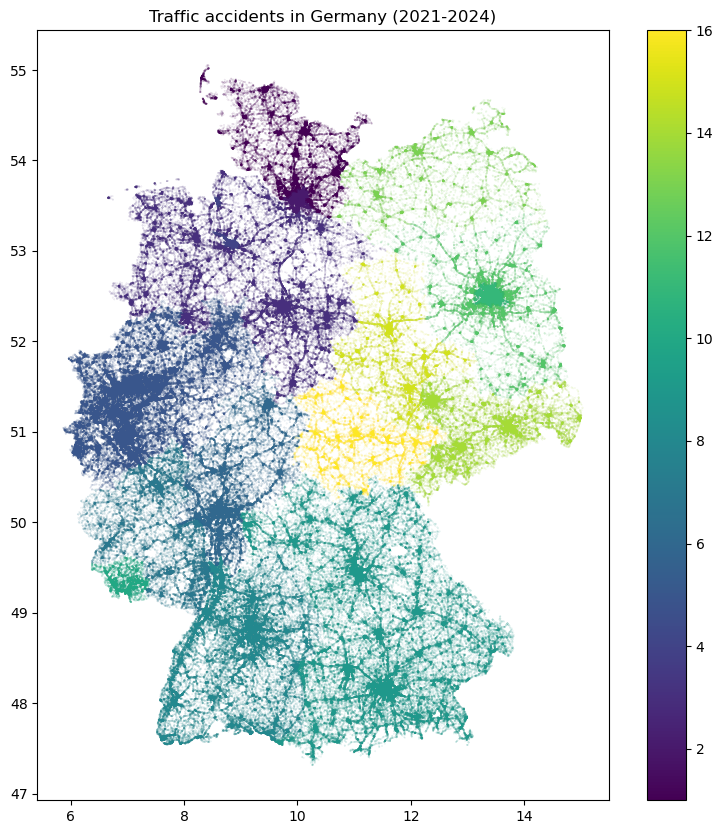

In [4]:
plot_germany(df, "Traffic accidents in Germany (2021-2024)")

Plot only the accidents with fatalities.


Number of accidents with fatalities in Germany (2021-2024): 9,679


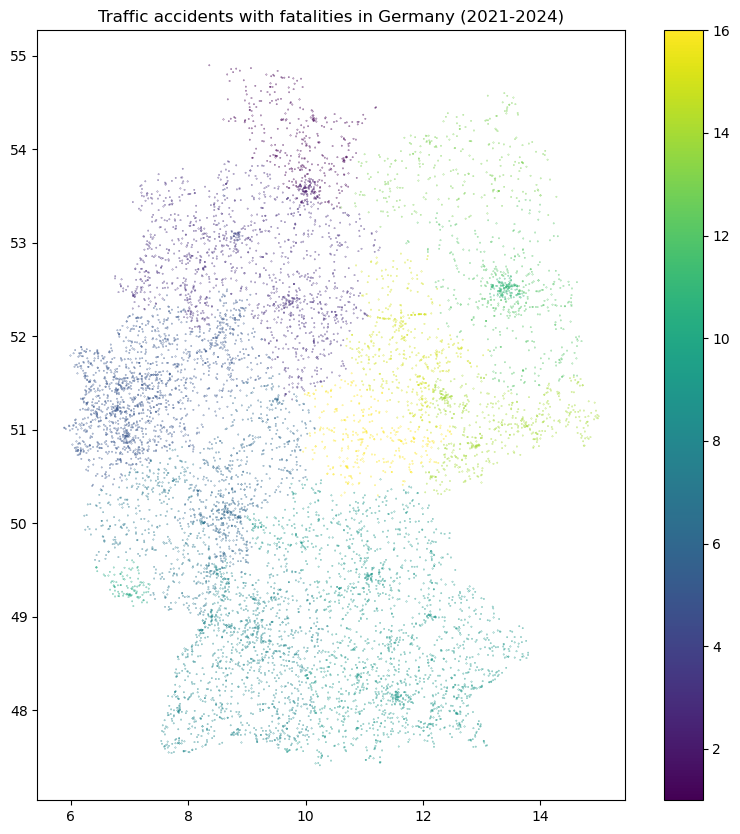

In [5]:
df_fatalities = df[df["UKATEGORIE"] == 1]
print(
    f"Number of accidents with fatalities in Germany (2021-2024): {len(df_fatalities):,}"
)
plot_germany(
    df_fatalities, "Traffic accidents with fatalities in Germany (2021-2024)", alpha=1.0
)

Plot only the accidents involving bicycles.


Number of accidents with bicycles in Germany (2021-2024): 333,091


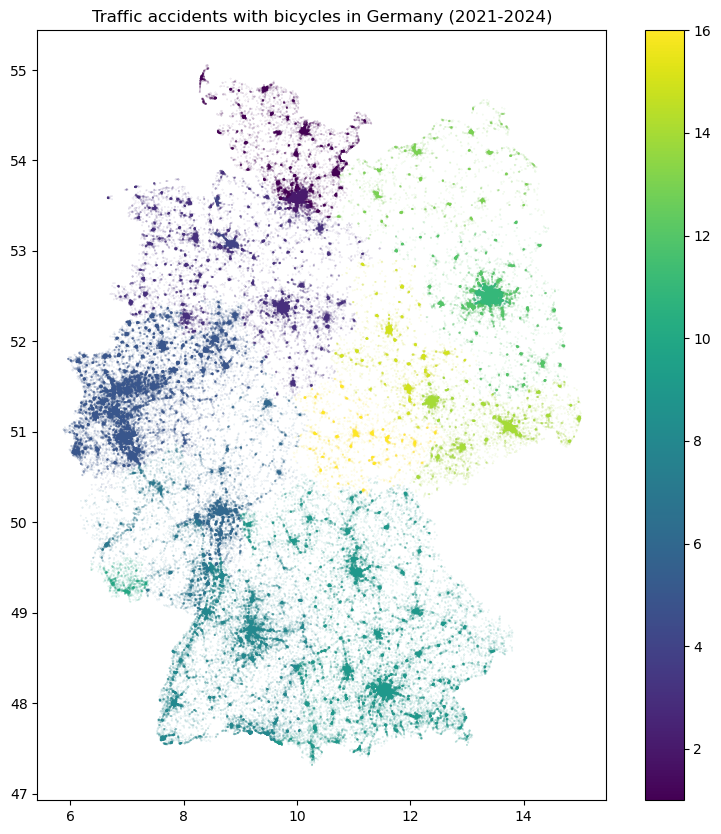

In [6]:
df_bikes = df[df["IstRad"] == 1]
print(f"Number of accidents with bicycles in Germany (2021-2024): {len(df_bikes):,}")
plot_germany(df_bikes, "Traffic accidents with bicycles in Germany (2021-2024)")

Plot only accidents with bicycles with fatalities


Number of accidents with bicycles with fatalities in Germany (2021-2024): 1,622


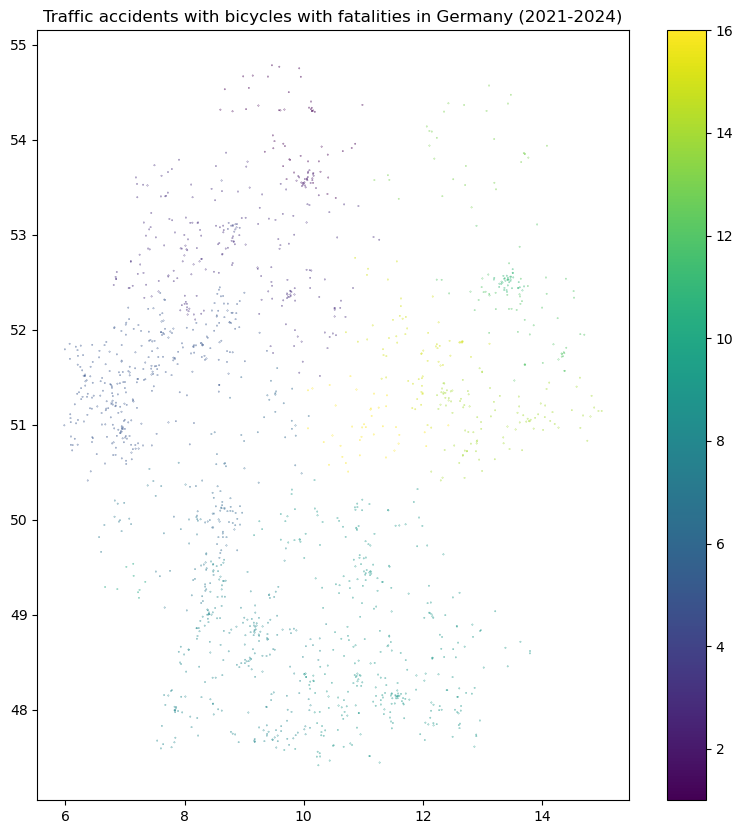

In [7]:
df_bike_fatalities = df_bikes[(df_bikes["UKATEGORIE"] == 1) & (df_bikes["IstRad"] == 1)]
print(
    f"Number of accidents with bicycles with fatalities in Germany (2021-2024): {len(df_bike_fatalities):,}"
)
plot_germany(
    df_bike_fatalities,
    "Traffic accidents with bicycles with fatalities in Germany (2021-2024)",
    alpha=1.0,
)